/opt/conda/envs/anaconda3-cuda/lib/python3.8/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[Warning] Fused window process have not been installed. Please refer to get_started.md for installation.
To use FusedLAMB or FusedAdam, please install apex.
=> merge config from /workspace/our_method/modules/swin_transformer/configs/simmim/ft_mocov_mcfp.yaml
[warning] Apex amp has been deprecated, please use pytorch amp instead!
RANK and WORLD_SIZE in environ: 0/1
[2026-01-10 00:02:59 simmim_barlow_finetune](1569441815.py 485): INFO {}


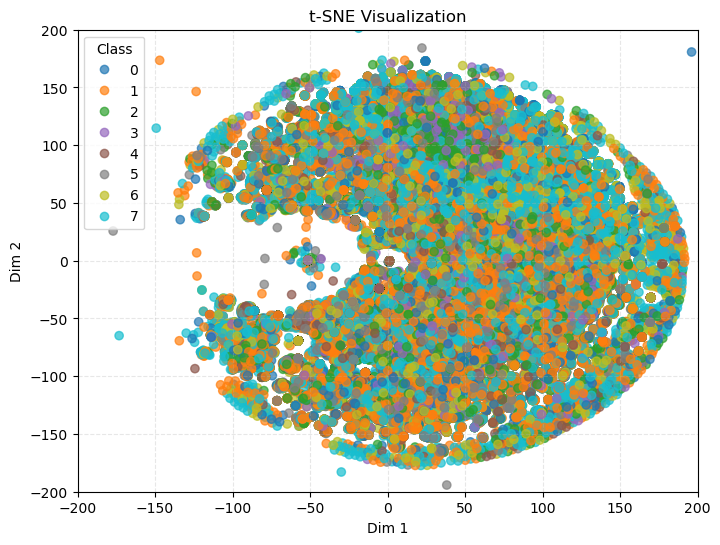

クラス：[0, 1, 2, 3, 4, 5, 6, 7]
カウント[10272, 10272, 10272, 10272, 10272, 10272, 10272, 10272]


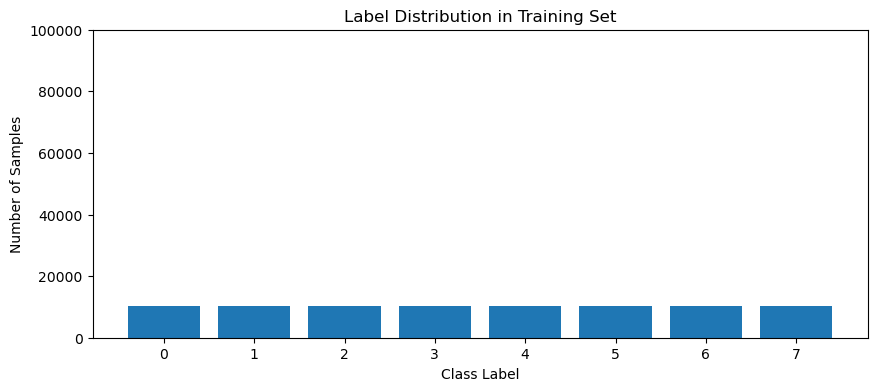

/opt/conda/envs/anaconda3-cuda/lib/python3.8/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1716905971873/work/aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


All checkpoints founded in ft_output/simmim_barlow_finetune/simmim_finetune__swin_base__img224_window7__800ep: []
[2026-01-10 00:48:48 simmim_barlow_finetune](1569441815.py 129): INFO no checkpoint found in ft_output/simmim_barlow_finetune/simmim_finetune__swin_base__img224_window7__800ep, ignoring auto resume
[2026-01-10 00:48:48 simmim_barlow_finetune](utils.py 149): INFO ==============> Loading weight /workspace/our_method/pt_output/swin_base_patch4_window7_224/default/ckpt_epoch_99.pth for fine-tuning......
[2026-01-10 00:48:49 simmim_barlow_finetune](utils.py 213): INFO => Pretrained weights loaded successfully from '/workspace/our_method/pt_output/swin_base_patch4_window7_224/default/ckpt_epoch_99.pth'
[2026-01-10 00:48:49 simmim_barlow_finetune](1569441815.py 309): INFO Valid: [0/1381]	Time 0.262 (0.262)	Loss 2.1418 (2.1418)	Acc@1 12.500 (12.500)	


/opt/conda/envs/anaconda3-cuda/lib/python3.8/site-packages/torch/utils/checkpoint.py:464: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/opt/conda/envs/anaconda3-cuda/lib/python3.8/site-packages/torch/utils/checkpoint.py:91: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


[2026-01-10 00:48:50 simmim_barlow_finetune](1569441815.py 309): INFO Valid: [100/1381]	Time 0.011 (0.014)	Loss 2.1477 (2.1410)	Acc@1 9.375 (11.200)	
[2026-01-10 00:48:51 simmim_barlow_finetune](1569441815.py 309): INFO Valid: [200/1381]	Time 0.012 (0.013)	Loss 2.0785 (2.1379)	Acc@1 23.438 (11.583)	
[2026-01-10 00:48:52 simmim_barlow_finetune](1569441815.py 309): INFO Valid: [300/1381]	Time 0.011 (0.013)	Loss 2.0954 (2.1369)	Acc@1 17.188 (11.773)	
[2026-01-10 00:48:54 simmim_barlow_finetune](1569441815.py 309): INFO Valid: [400/1381]	Time 0.011 (0.013)	Loss 2.1247 (2.1377)	Acc@1 14.062 (11.713)	
[2026-01-10 00:48:55 simmim_barlow_finetune](1569441815.py 309): INFO Valid: [500/1381]	Time 0.011 (0.012)	Loss 2.1147 (2.1373)	Acc@1 14.062 (11.686)	
[2026-01-10 00:48:56 simmim_barlow_finetune](1569441815.py 309): INFO Valid: [600/1381]	Time 0.012 (0.012)	Loss 2.1616 (2.1378)	Acc@1 7.812 (11.569)	
[2026-01-10 00:48:57 simmim_barlow_finetune](1569441815.py 309): INFO Valid: [700/1381]	Time 0.0

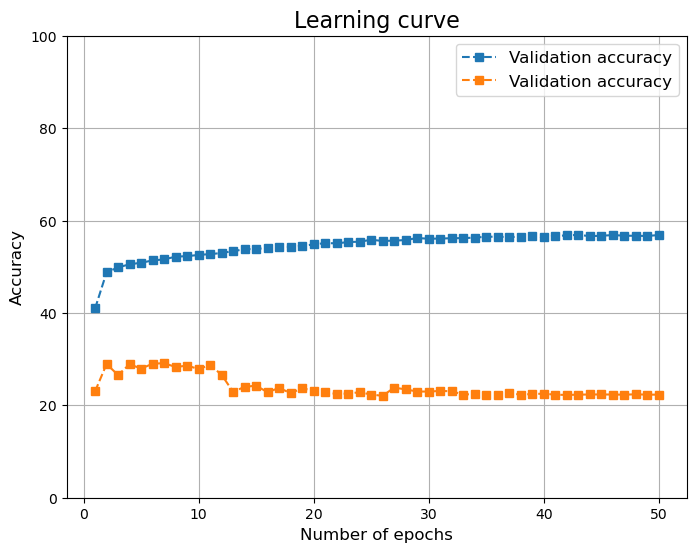

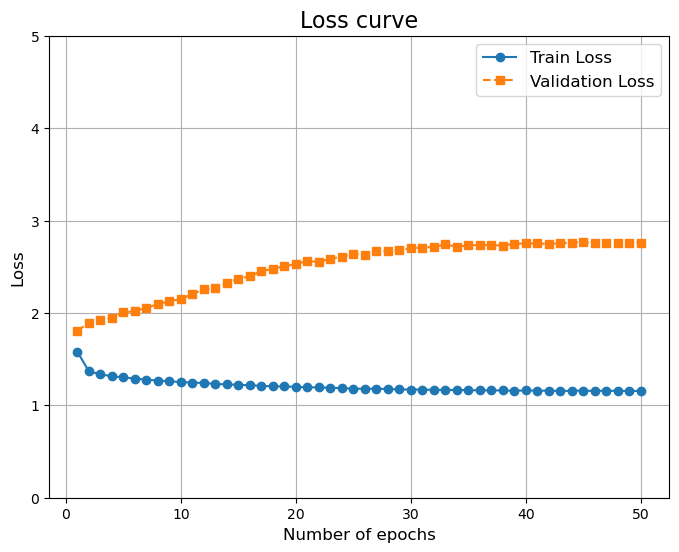

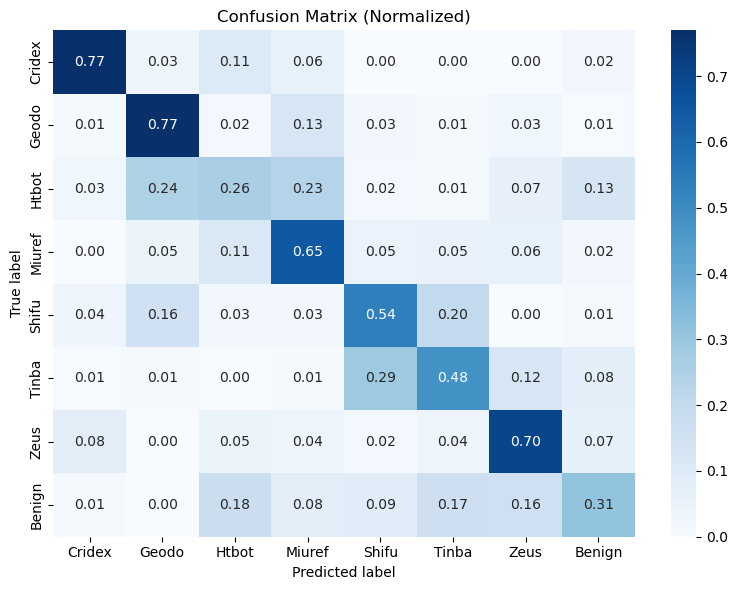

In [1]:
import os
import time
import json
import random
import argparse
import datetime
import numpy as np
import ast

import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
import torch.distributed as dist
from torch.utils.data import Dataset
from torch import optim
from PIL import Image

from data import build_loader
from modules.swin_transformer.config import get_config
from modules.swin_transformer.models import build_model
from modules.swin_transformer.lr_scheduler import build_scheduler
from modules.swin_transformer.optimizer import build_optimizer
from modules.swin_transformer.logger import create_logger
from modules.swin_transformer.utils import load_checkpoint, load_pretrained, save_checkpoint, NativeScalerWithGradNormCount, auto_resume_helper, \
    reduce_tensor

from modules.gnn.models.gat import GAT as gat
from modules.gnn.models.fast_gcn import FastGCN as fast
from modules.gnn.models.comb_gnn import CombinedGNN
from modules.comb_module import CombinedModule as comb_module

# 評価用
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from timm.loss import LabelSmoothingCrossEntropy, SoftTargetCrossEntropy
from timm.utils import accuracy, AverageMeter
from our_method.data.create_dataset.data_dist import data_distribution
from matplotlib import pyplot as plt
from PIL import Image

# pytorch major version (1.x or 2.x)
PYTORCH_MAJOR_VERSION = int(torch.__version__.split('.')[0])

# 参照元のコードはコマンドラインで引数を指定
# jupyter lab上で機能するように、引数
def parse_option():
    class Args:
        cfg = "/workspace/our_method/modules/swin_transformer/configs/simmim/ft_mocov_mcfp.yaml"
        opts  = None
        data_path = ["/workspace/dataset/mcfp/parsed_raw", "/workspace/dataset/mcfp/graph"]
        zip = False
        cache_mode = 'part'
        resume = None
        accumulation_steps = 4
        use_checkpoint =  True
        disable_amp = False
        amp_opt_level = '01'
        output = 'ft_output'
        tag = None
        eval = False
        throughput = False
        os.environ['RANK'] = '0'
        os.environ['LOCAL_RANK'] = '0'  
        os.environ['WORLD_SIZE'] = '1'
        os.environ['MASTER_ADDR'] = 'localhost'
        os.environ['MASTER_PORT'] = '29500'
        fused_window_process = False
        fused_layernorm = False
        optim = 'adamw'

    # 引数をインスタンス化
    args = Args()

    # configファイルの読み込みや設定を行う関数を呼び出し
    config = get_config(args)

    return args, config

def main(config, device):
    combined_train, combined_test, combined_val, combined_dataloader_train, combined_dataloader_test, combined_dataloader_val, mixup_fn = build_loader(config, simmim=True, is_pretrain=False)

    # データ（ラベル）分布の表示
    data_distribution(combined_train)
    
    # gnnのパラメータ
    graph_dataset, raw_dataset = combined_train[0]
    features = graph_dataset["graph"][0].ndata["feat"]
    in_dim = features.shape[1]

    #モデルの構築
    swin_model = build_model(config)
    gat_model = gat(config, in_dim, device)
    fast_model = fast(config, in_dim, device)

    # 融合モデルの作成
    gnn_comb = CombinedGNN(config, gat_model, fast_model, device)
    comb_model = comb_module(config, gnn_comb, swin_model, device)
    comb_params = comb_model.parameters()

    optimizer = optim.AdamW(comb_params, lr=config.TRAIN.BASE_LR, weight_decay=config.TRAIN.WEIGHT_DECAY)
    loss_scaler = NativeScalerWithGradNormCount()

    if config.TRAIN.ACCUMULATION_STEPS > 1:
        lr_scheduler = build_scheduler(config, optimizer, len(combined_dataloader_train) // config.TRAIN.ACCUMULATION_STEPS)
    else:
        lr_scheduler = build_scheduler(config, optimizer, len(combined_dataloader_train))

    if config.AUG.MIXUP > 0.:
        # smoothing is handled with mixup label transform
        criterion = SoftTargetCrossEntropy()
    elif config.MODEL.LABEL_SMOOTHING > 0.:
        criterion = LabelSmoothingCrossEntropy(smoothing=config.MODEL.LABEL_SMOOTHING)
    else:
        criterion = torch.nn.CrossEntropyLoss()

    max_accuracy = 0.0

    if config.TRAIN.AUTO_RESUME:
        resume_file = auto_resume_helper(config.OUTPUT)
        if resume_file:
            if config.MODEL.RESUME:
                logger.warning(f"auto-resume changing resume file from {config.MODEL.RESUME} to {resume_file}")
            config.defrost()
            config.MODEL.RESUME = resume_file
            config.freeze()
            logger.info(f'auto resuming from {resume_file}')
        else:
            logger.info(f'no checkpoint found in {config.OUTPUT}, ignoring auto resume')

    # 前回学習地点の読み込み
    if config.MODEL.RESUME:
        max_accuracy = load_checkpoint(config, comb_model, optimizer, lr_scheduler, scaler, logger)
        acc1, loss = validate(config, combined_dataloader_val, comb_model, criterion)
        logger.info(f"Accuracy of the network on the {len(combined_val)} test images: {acc1:.1f}%")
        if config.EVAL_MODE:
            return

    # 事前学習済みモデルの読み込み
    if config.MODEL.PRETRAINED and (not config.MODEL.RESUME):
        load_pretrained(config, gnn_comb, swin_model, logger)
        acc1, loss = validate(config, combined_dataloader_val, comb_model, criterion)
        logger.info(f"Accuracy of the network on the {len(combined_val)} test images: {acc1:.1f}%")
    
    # train
    logger.info("Start training")
    start_time = time.time()
    train_accs_avg = []
    train_loss_avg = []
    val_accs_avg = []
    val_loss_avg = []
    all_pred = []
    all_target = []
    
    for epoch in range(config.TRAIN.START_EPOCH, config.TRAIN.EPOCHS):
        combined_dataloader_train.sampler.set_epoch(epoch)
        acc1, loss, y_pred, y_true = train_one_epoch(config, comb_model, criterion, combined_dataloader_train, optimizer, epoch, mixup_fn, lr_scheduler,
                        loss_scaler, comb_params)
        train_accs_avg.append(acc1)
        train_loss_avg.append(loss)
        all_pred.append(y_pred.cpu())
        all_target.append(y_true.cpu())

        acc1, loss = validate(config, combined_dataloader_val, comb_model, criterion)
        val_accs_avg.append(acc1)
        val_loss_avg.append(loss)
        logger.info(f"Accuracy of the network on the {len(combined_val)} val images: {acc1:.1f}%")
        max_accuracy = max(max_accuracy, acc1)
        logger.info(f'Max accuracy: {max_accuracy:.2f}%')

    total_time = time.time() - start_time
    total_time_str = str(datetime.timedelta(seconds=int(total_time)))
    logger.info('Training time {}'.format(total_time_str))

    # test
    logger.info("Start testing")
    acc, precision, recall, f1, pred_avetime = test(config, combined_dataloader_test, comb_model)
    logger.info(f'Macro_Acc:{acc}%')
    logger.info(f'Macro Precision: {precision}')
    logger.info(f'Macro Recall: {recall}')
    logger.info(f'Macro F1-Score: {f1}')
    logger.info(f'Macro Prediction Average Time: {pred_avetime:.4f}')

    # 学習曲線の描画
    draw_train_curb(train_accs_avg, val_accs_avg)
    draw_loss_curb(train_loss_avg, val_loss_avg)
    # 混同行列の描画
    plot_confusion_matrix(all_pred, all_target, config.MODEL.LABEL, normalize='true')


def train_one_epoch(config, comb_model, criterion, combined_dataloader, optimizer, epoch, mixup_fn, lr_scheduler, loss_scaler, comb_params):
    comb_model.train()
    optimizer.zero_grad()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    training=True
    
    num_steps = len(combined_dataloader)
    batch_time = AverageMeter()
    loss_meter = AverageMeter()
    norm_meter = AverageMeter()
    scaler_meter = AverageMeter()
    acc1_meter = AverageMeter()

    start = time.time()
    end = time.time()

    for idx, (batched_raw, batched_graph, batched_label) in enumerate(combined_dataloader):       
        batched_raw = batched_raw.cuda(non_blocking=True)
        batched_graph = batched_graph.to(device)
        targets = batched_label.cuda(non_blocking=True)
       
        with torch.cuda.amp.autocast(dtype=torch.float32):
            logits = comb_model(batched_raw, batched_graph, training)

        loss = criterion(logits, targets)
        
        target_index = torch.argmax(targets, dim=1)
        
        acc1, acc5 = accuracy(logits, target_index, topk=(1,5))
        acc1 = reduce_tensor(acc1)
        acc1_meter.update(acc1.item(), target_index.size(0))

        # 混同行列用出力
        y_pred = torch.argmax(logits, dim=1)
        y_true = target_index

        # this attribute is added by timm on one optimizer (adahessian)
        is_second_order = hasattr(optimizer, 'is_second_order') and optimizer.is_second_order
        grad_norm = loss_scaler(loss, optimizer, clip_grad=config.TRAIN.CLIP_GRAD,
                                parameters=comb_params, create_graph=is_second_order,
                                update_grad=(idx + 1) % config.TRAIN.ACCUMULATION_STEPS == 0)
        
        if (idx + 1) % config.TRAIN.ACCUMULATION_STEPS == 0:
            optimizer.zero_grad()
            lr_scheduler.step_update((epoch * num_steps + idx) // config.TRAIN.ACCUMULATION_STEPS)
        
        loss_scale_value = loss_scaler.state_dict()["scale"]

        torch.cuda.synchronize()

        loss_meter.update(loss.item(), targets.size(0))
        if grad_norm is not None:  
            # loss_scaler return None if not update
            norm_meter.update(grad_norm)
        scaler_meter.update(loss_scale_value)
        batch_time.update(time.time() - end)
        end = time.time()

        if idx % config.PRINT_FREQ == 0:
            lr = optimizer.param_groups[0]['lr']
            wd = optimizer.param_groups[0]['weight_decay']
            memory_used = torch.cuda.max_memory_allocated() / (1024.0 * 1024.0)
            etas = batch_time.avg * (num_steps - idx)
            logger.info(
                f'Train: [{epoch}/{config.TRAIN.EPOCHS}][{idx}/{num_steps}]\t'
                f'eta {datetime.timedelta(seconds=int(etas))} lr {lr:.6f}\t wd {wd:.4f}\t'
                f'time {batch_time.val:.4f} ({batch_time.avg:.4f})\t'
                f'loss {loss_meter.val:.4f} ({loss_meter.avg:.4f})\t'
                f'grad_norm {norm_meter.val:.4f} ({norm_meter.avg:.4f})\t'
                f'loss_scale {scaler_meter.val:.4f} ({scaler_meter.avg:.4f})\t'
            )
            
    epoch_time = time.time() - start
    logger.info(f"EPOCH {epoch} training takes {datetime.timedelta(seconds=int(epoch_time))}")
    return acc1_meter.avg, loss_meter.avg, y_pred, y_true

@torch.no_grad()
def validate(config, combined_dataloader, comb_model, criterion):
    comb_model.eval()
    training=False

    # 損失やloss, accの平均を一括保管するライブラリ
    batch_time = AverageMeter()
    loss_meter = AverageMeter()
    acc1_meter = AverageMeter()
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    end = time.time()

    # 追加（デバッグ用）
    with torch.no_grad():
        for idx, (batched_raw, batched_graph, batched_label) in enumerate(combined_dataloader):
            batched_raw = batched_raw.cuda(non_blocking=True)
            batched_graph = batched_graph.to(device)
            targets = batched_label.cuda(non_blocking=True)
        
            # compute output
            with torch.cuda.amp.autocast(dtype=torch.float32):
                logits = comb_model(batched_raw, batched_graph, training)
        
            loss = criterion(logits, targets)
            targets = torch.argmax(targets, dim=1)
            acc1,acc5 = accuracy(logits, targets, topk=(1,5))

            # 各GPUで計算したaccとlossを平均化（分散処理）
            acc1 = reduce_tensor(acc1)
            loss = reduce_tensor(loss)

            loss_meter.update(loss.item(), targets.size(0))
            acc1_meter.update(acc1.item(), targets.size(0))

            # measure elapsed time
            batch_time.update(time.time() - end)
            end = time.time()

            if idx % config.PRINT_FREQ == 0:
                memory_used = torch.cuda.max_memory_allocated() / (1024.0 * 1024.0)
                logger.info(
                    f'Valid: [{idx}/{len(combined_dataloader)}]\t'
                    f'Time {batch_time.val:.3f} ({batch_time.avg:.3f})\t'
                    f'Loss {loss_meter.val:.4f} ({loss_meter.avg:.4f})\t'
                    f'Acc@1 {acc1_meter.val:.3f} ({acc1_meter.avg:.3f})\t'
                )
            
    return acc1_meter.avg, loss_meter.avg

@torch.no_grad()
def test(config, combined_dataloader, comb_model):
    comb_model.eval()
    training=False

    # 損失やloss, accの平均を一括保管するライブラリ
    batch_time = AverageMeter()
    
    # 評価用の配列
    all_batch_times = []
    all_logits = []
    all_targets = []
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    end = time.time()

    with torch.no_grad():
        for idx, (batched_raw, batched_graph, batched_label) in enumerate(combined_dataloader):
            batched_raw = batched_raw.cuda(non_blocking=True)
            batched_graph = batched_graph.to(device)
            targets = batched_label.cuda(non_blocking=True)
            targets = torch.argmax(targets, dim=1)
        
            # compute output
            with torch.cuda.amp.autocast(dtype=torch.float32):
                logits = comb_model(batched_raw, batched_graph, training)

            # Precision, Recall, F1-Scoreの算出用
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())

            # measure elapsed time
            batch_time.update(time.time() - end)
            end = time.time()

        # マクロ平均の Accuracy / Precision / Recall / F1 を計算
        acc, precision, recall, f1, = calc_macro_metrix(all_logits, all_targets)

    return acc, precision, recall, f1, batch_time.avg

# 学習時間を計測
@torch.no_grad()
def throughput(data_loader, model, logger):
    model.eval()

    for idx, (images, _) in enumerate(data_loader):
        images = images.cuda(non_blocking=True)
        batch_size = images.shape[0]
        for i in range(50):
            model(images)
        torch.cuda.synchronize()
        logger.info(f"throughput averaged with 30 times")
        tic1 = time.time()
        for i in range(30):
            model(images)
        torch.cuda.synchronize()
        tic2 = time.time()
        logger.info(f"batch_size {batch_size} throughput {30 * batch_size / (tic2 - tic1)}")
        return

def draw_train_curb(train_acc_avg, test_acc_avg):
    epochs = list(range(1, len(train_acc_avg) + 1))
    plt.figure(figsize=(8,6))
    plt.plot(epochs, train_acc_avg, marker='s', linestyle='--', label='Validation accuracy')
    plt.plot(epochs, test_acc_avg, marker='s', linestyle='--', label='Validation accuracy')
    plt.grid()
    plt.title('Learning curve', fontsize=16)
    plt.xlabel('Number of epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(fontsize=12)
    plt.ylim([0, 100])
    plt.show()

def draw_loss_curb(train_loss_avg, test_loss_avg):
    epochs = list(range(1, len(train_loss_avg) + 1))
    plt.figure(figsize=(8,6))
    plt.plot(epochs, train_loss_avg, marker='o', label='Train Loss')
    plt.plot(epochs, test_loss_avg, marker='s', linestyle='--', label='Validation Loss')
    plt.grid()
    plt.title('Loss curve', fontsize=16)
    plt.xlabel('Number of epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.ylim([0, 5])
    plt.show()

def plot_confusion_matrix(all_pred, all_target, class_names, normalize='true'):
    y_pred = torch.cat(all_pred).numpy()
    y_true = torch.cat(all_target).numpy()
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.tight_layout()
    plt.show()

def calc_macro_metrix(all_logits, all_targets):
    # 結合（logits を argmax でクラス化）
    all_preds = torch.cat(all_logits).argmax(dim=1).numpy()
    all_labels = torch.cat(all_targets).numpy()

    # precision, recall, f1
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    acc = accuracy_score(all_labels, all_preds)
    return acc, precision, recall, f1

if __name__ == '__main__':
    args, config = parse_option()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if config.AMP_OPT_LEVEL:
        print("[warning] Apex amp has been deprecated, please use pytorch amp instead!")

    if 'MASTER_PORT' not in os.environ:
        os.environ['MASTER_PORT'] = str(config.DISTRIBUTED.PORT)
    
    if 'RANK' in os.environ and 'WORLD_SIZE' in os.environ:
        rank = int(os.environ["RANK"])
        world_size = int(os.environ['WORLD_SIZE'])
        print(f"RANK and WORLD_SIZE in environ: {rank}/{world_size}")
    else:
        rank = -1
        world_size = -1
    torch.cuda.set_device(config.LOCAL_RANK)

    if config.DISTRIBUTED.ENABLE and not torch.distributed.is_initialized():
        torch.distributed.init_process_group(
            backend=config.DISTRIBUTED.BACKEND,
            init_method=config.DISTRIBUTED.INIT_METHOD,
            world_size=world_size,
            rank=rank
        )
        torch.distributed.barrier()

    seed = config.SEED + dist.get_rank()
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    cudnn.benchmark = True

    # linear scale the learning rate according to total batch size, may not be optimal
    #linear_scaled_lr = config.TRAIN.BASE_LR * config.DATA.BATCH_SIZE * dist.get_world_size() / 512.0
    linear_scaled_warmup_lr = config.TRAIN.WARMUP_LR * config.DATA.BATCH_SIZE * dist.get_world_size() / 512.0
    linear_scaled_min_lr = config.TRAIN.MIN_LR * config.DATA.BATCH_SIZE * dist.get_world_size() / 512.0
    # gradient accumulation also need to scale the learning rate
    if config.TRAIN.ACCUMULATION_STEPS > 1:
        #linear_scaled_lr = linear_scaled_lr * config.TRAIN.ACCUMULATION_STEPS
        linear_scaled_warmup_lr = linear_scaled_warmup_lr * config.TRAIN.ACCUMULATION_STEPS
        linear_scaled_min_lr = linear_scaled_min_lr * config.TRAIN.ACCUMULATION_STEPS
    config.defrost()
    
    #config.TRAIN.BASE_LR = linear_scaled_lr
    config.TRAIN.WARMUP_LR = linear_scaled_warmup_lr
    config.TRAIN.MIN_LR = linear_scaled_min_lr
# pytorch major version (1.x or 2.x)

    os.makedirs(config.OUTPUT, exist_ok=True)
    logger = create_logger(output_dir=config.OUTPUT, dist_rank=dist.get_rank(), name=f"{config.MODEL.NAME}")

    # print config
    #logger.info(config.dump())
    logger.info(json.dumps(vars(args)))

    main(config, device)